In [1]:
pip install pandas numpy scikit-learn seaborn flask joblib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import pickle

In [3]:
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [4]:
df = pd.read_csv("data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
df.shape

(569, 33)

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df = df.drop(columns=["Unnamed: 32"])
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [8]:
df["diagnosis"].unique()

array(['M', 'B'], dtype=object)

In [9]:
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])
df["diagnosis"]

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [10]:
x= df.drop("diagnosis",axis=1)
y = df["diagnosis"]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [12]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [13]:
lr = LogisticRegression(max_iter=10000)
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [14]:
y_pred = lr.predict(x_test)

In [15]:
acc = accuracy_score(y_test,y_pred)*100
print("Model Accuracy: ",acc)

Model Accuracy:  97.36842105263158


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [17]:
print(confusion_matrix(y_test,y_pred))

[[70  1]
 [ 2 41]]


In [18]:
# import pickle

# pickle.dump(lr, open("D:\\breast cancer\\model\\breast_cancer_model.pkl", "wb"))

In [19]:
# pickle.dump(sc,open("D:\\breast cancer\\model\\scaler.pkl","wb"))

In [20]:
# print("Model Saved Successfully")

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [22]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
y_pred = dt.predict(x_test)

In [24]:
acc_dt = accuracy_score(y_test,y_pred)*100
print("Model Accuracy: ",acc_dt)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Model Accuracy:  93.85964912280701
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

[[67  4]
 [ 3 40]]


In [25]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred = knn.predict(x_test)
acc_knn = accuracy_score(y_test,y_pred)*100
print("Model Accuracy: ",acc_knn)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Model Accuracy:  94.73684210526315
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

[[68  3]
 [ 3 40]]


In [27]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = rf.predict(x_test)
acc_rf = accuracy_score(y_test,y_pred)*100
print("Model Accuracy: ",acc_rf)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Model Accuracy:  96.49122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[70  1]
 [ 3 40]]


In [29]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(x_train, y_train)

# Predictions
y_pred_grid = grid_lr.predict(x_test)

print("GridSearch Best Params:", grid_lr.best_params_)
print("GridSearch Accuracy:", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
GridSearch Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
GridSearch Accuracy: 0.9912280701754386


In [30]:
from scipy.stats import uniform

param_dist = {
    'C': uniform(0.01, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_lr = RandomizedSearchCV(
    lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_lr.fit(x_train, y_train)

# Predictions
y_pred_rand = random_lr.predict(x_test)

print("RandomSearch Best Params:", random_lr.best_params_)
print("RandomSearch Accuracy:", accuracy_score(y_test, y_pred_rand))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomSearch Best Params: {'C': np.float64(5.818361216819946), 'penalty': 'l2', 'solver': 'liblinear'}
RandomSearch Accuracy: 0.9736842105263158


In [31]:
# knn
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

# Prediction
y_pred_grid = grid_knn.predict(x_test)

print("Grid Best Params:", grid_knn.best_params_)
print("Grid Accuracy:", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Grid Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Grid Accuracy: 0.9473684210526315


In [32]:
from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

random_knn = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_knn.fit(x_train, y_train)

# Prediction
y_pred_rand = random_knn.predict(x_test)

print("Random Best Params:", random_knn.best_params_)
print("Random Accuracy:", accuracy_score(y_test, y_pred_rand))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Best Params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Random Accuracy: 0.9649122807017544


In [33]:
param_grid = {
    'max_depth': [None, 3, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(x_train, y_train)

# Prediction
y_pred_grid = grid_dt.predict(x_test)

print("Grid Best Params:", grid_dt.best_params_)
print("Grid Accuracy:", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Grid Best Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Grid Accuracy: 0.956140350877193


In [41]:
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

# Randomized Search
random_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=20,         # number of combinations
    cv=5,              # cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Train
random_dt.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", random_dt.best_params_)

# Best model
best_model = random_dt.best_estimator_

# Accuracy
accuracy = best_model.score(x_test, y_test)
print("Accuracy:", accuracy)

Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'criterion': 'entropy'}
Accuracy: 0.9385964912280702


In [34]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

# Prediction
y_pred_grid = grid_rf.predict(x_test)

print("Grid Best Params:", grid_rf.best_params_)
print("Grid Accuracy:", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Grid Best Params: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Grid Accuracy: 0.9649122807017544


In [35]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_rf.fit(x_train, y_train)

# Prediction
y_pred_rand = random_rf.predict(x_test)

print("Random Best Params:", random_rf.best_params_)
print("Random Accuracy:", accuracy_score(y_test, y_pred_rand))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Best Params: {'bootstrap': False, 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 253}
Random Accuracy: 0.9649122807017544


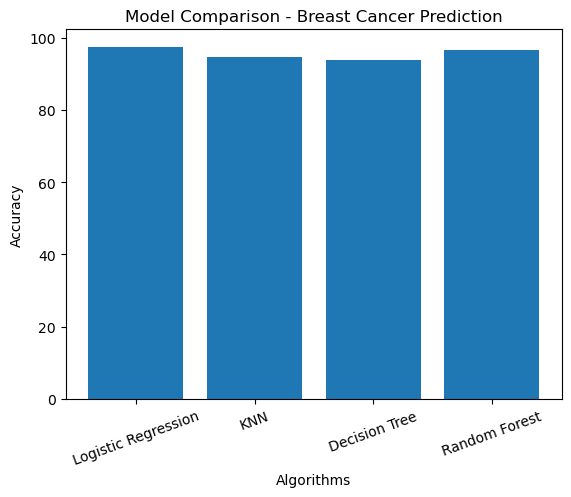

In [36]:
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

accuracies = [acc, acc_knn, acc_dt, acc_rf]  # replace with your results

import matplotlib.pyplot as plt

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Breast Cancer Prediction")

plt.xticks(rotation=20)

plt.show()

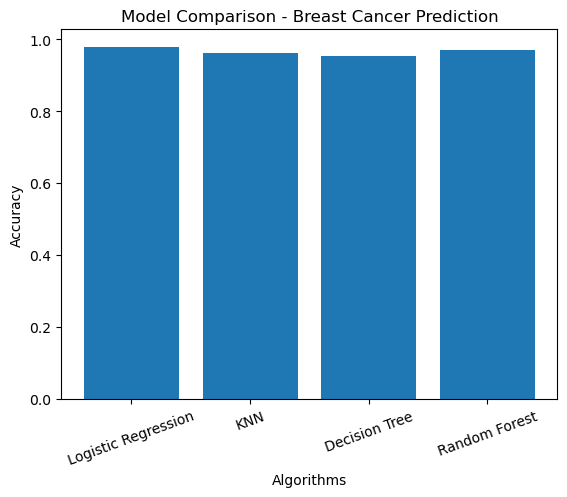

In [37]:
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

accuracies = [    grid_lr.best_score_,
    grid_knn.best_score_,
    grid_dt.best_score_,
    grid_rf.best_score_
]  # replace with your results

import matplotlib.pyplot as plt

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Breast Cancer Prediction")

plt.xticks(rotation=20)

plt.show()

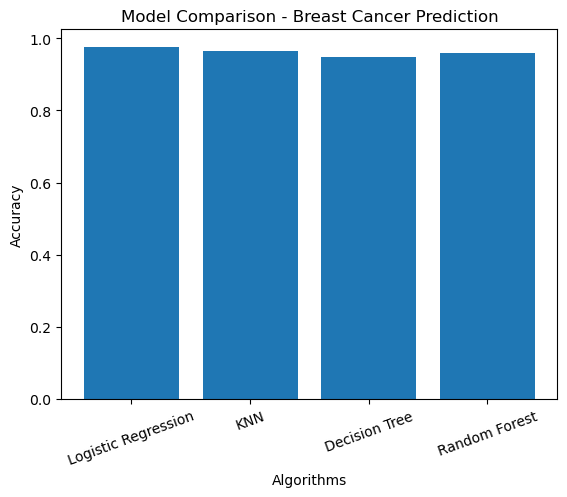

In [42]:
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

accuracies = [    random_lr.best_score_,
    random_knn.best_score_,
    random_dt.best_score_,
    random_rf.best_score_
]  # replace with your results

import matplotlib.pyplot as plt

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Breast Cancer Prediction")

plt.xticks(rotation=20)

plt.show()

In [44]:
print("Train Accuracy:", best_model.score(x_train, y_train))
print("Test Accuracy:", best_model.score(x_test, y_test))

Train Accuracy: 0.989010989010989
Test Accuracy: 0.9385964912280702


In [49]:
# Logistic Regression (Top accuracy)
# OR Random Forest (more robust),  Overfitting kam hota hai, Real-world data me stable


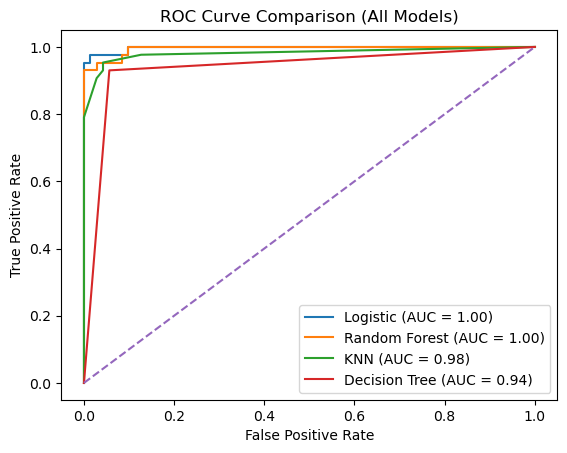

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
lr_prob = lr.predict_proba(x_test)[:, 1]
rf_prob = rf.predict_proba(x_test)[:, 1]
knn_prob = knn.predict_proba(x_test)[:, 1]
dt_prob = dt.predict_proba(x_test)[:, 1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

# AUC scores
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
knn_auc = auc(knn_fpr, knn_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

# Plot
plt.figure()

plt.plot(lr_fpr, lr_tpr, label="Logistic (AUC = %0.2f)" % lr_auc)
plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %0.2f)" % rf_auc)
plt.plot(knn_fpr, knn_tpr, label="KNN (AUC = %0.2f)" % knn_auc)
plt.plot(dt_fpr, dt_tpr, label="Decision Tree (AUC = %0.2f)" % dt_auc)

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend(loc="lower right")

plt.show()

In [54]:
“I evaluated multiple models using accuracy and ROC-AUC. Logistic Regression and Random Forest achieved the highest AUC of 1.0. I selected Random Forest as the final model due to its robustness and better generalization.”
final_model = random_rf

In [55]:
import pickle

pickle.dump(final_model, open("D:\\breast cancer\\model\\breast_cancer_model.pkl", "wb"))

In [56]:
 pickle.dump(sc,open("D:\\breast cancer\\model\\scaler.pkl","wb"))

In [57]:
print("Model Saved Successfully")

Model Saved Successfully
